
### Part 1: Understanding Product Categories
1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [7]:
# Importing the Seaborn library for advanced data visualization (as sns)
import seaborn as sns

# Importing the Matplotlib library for basic plotting functionalities (as plt)
import matplotlib.pyplot as plt

# Importing the Pandas library for data manipulation and analysis (as pd)
import pandas as pd

# Importing the NumPy library for numerical operations (as np)
import numpy as np

In [8]:
df = pd.read_csv( r"C:\Users\nahia\OneDrive\Escritorio\Bootcamp\Week2\Labs\lab-eda-univariate\amz_uk_price_prediction_dataset.csv")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2443631 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 170.1+ MB


In [10]:
frequency_table = df.category.value_counts()


In [11]:
print(frequency_table)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64


In [12]:
df.category.value_counts().head(10)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [13]:
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'title_frequency']
subset = category_counts.head (5)

C:\Users\nahia\AppData\Local\Temp\ipykernel_37676\1667856421.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


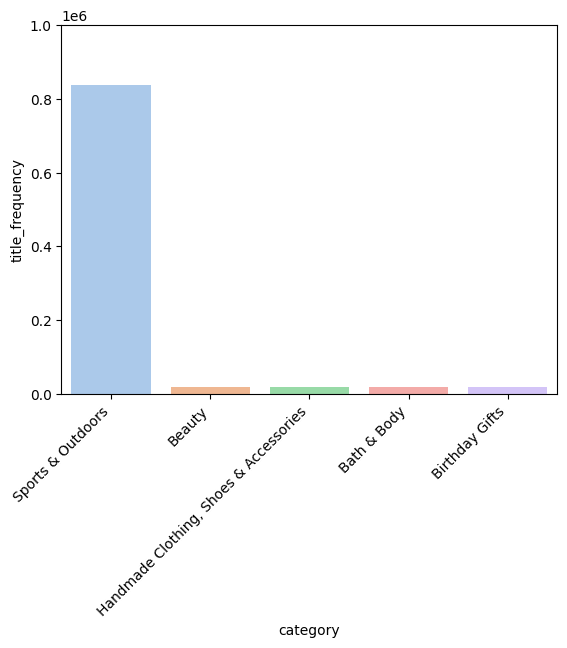

In [14]:
sns.barplot(
    x="category",
    y='title_frequency',
    data= subset,
    palette='pastel',
    legend=True,
  
 )
plt.ylim(0, 1000000),
plt.xticks(rotation=45, ha="right")
plt.show()


### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.

In [65]:
df_new = df[df["price"] != 0]

In [66]:
df_new["price"].mean()


np.float64(89.24453985892305)

In [67]:
df_new["price"].median()


np.float64(19.09)

In [69]:
df_new["price"].mode()

0    9.99
Name: price, dtype: float64

    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

The average price point is 90% higher than the mode, that means even when the majority of the customer buy products with a relatively low cost, there are few products with a higher price that have an impact on the mean calculation.
We assume there are "few" products with higher cost having an impact on the mean calculation, because the median is closer to the mode. 


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.


### standard deviation

In [71]:
df_new["price"].std()

np.float64(345.6101817706156)

### variance

In [72]:
df_new["price"].var()

np.float64(119446.39774351795)

###  range

In [73]:
df_new["price"].max()

np.float64(100000.0)

In [74]:

df_new["price"].min()

np.float64(0.01)

In [75]:
range = df["price"].max() - df["price"].min()
range

np.float64(99999.99)

### interquartile range

In [76]:
import numpy as np

In [77]:
Q1 = np.percentile(df["price"], 25)
Q3 = np.percentile(df["price"], 75)

In [54]:
IQR = Q3 - Q1
print(IQR)

36.0


    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [ ]:
The product prices are very varied. The standar deviation value indicates a significant spread

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.


In [95]:
bins =  [0, 10, 20, 30, 50, 100, 200, 500, 1000, df_new["price"].max()]
labels = ["0-10", "11-20", "21-30", "31-50", "51-100", "101-200", "201-500", "501-1000", "1000+"]

In [96]:
df_new["price_range"] = pd.cut(df["price"], bins=bins, labels=labels, include_lowest=True)
price_counts = df_new["price_range"].value_counts().sort_index()

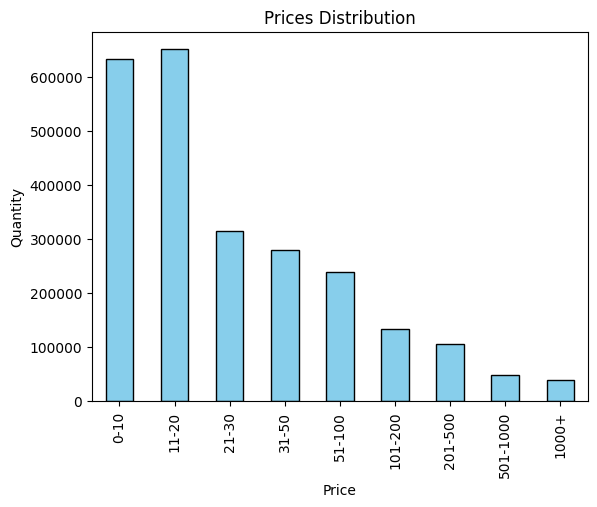

In [97]:

price_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Prices Distribution")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show()

  - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 


In [92]:
import pandas as pd
import matplotlib.pyplot as plt

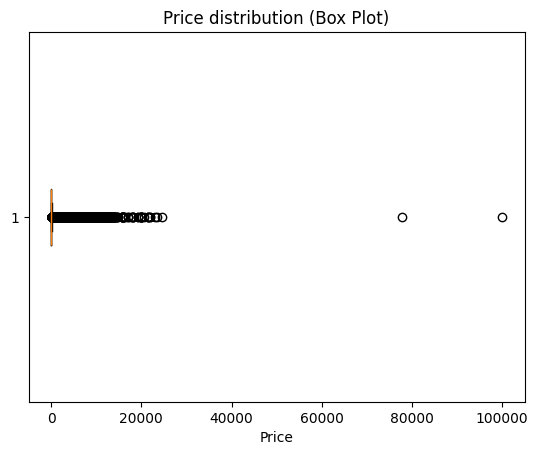

In [94]:
plt.boxplot(df["price"], vert=False)
plt.title("Price distribution (Box Plot)")
plt.xlabel("Price")
plt.show()

In [106]:
df_sin_outliers = df[(df['price'] >= 0.01) & (df['price'] <= 30000)]

### Measures of Centrality:

###  mean for the rating of products

In [26]:
# Importing the Seaborn library for advanced data visualization (as sns)
import seaborn as sns

# Importing the Matplotlib library for basic plotting functionalities (as plt)
import matplotlib.pyplot as plt

# Importing the Pandas library for data manipulation and analysis (as pd)
import pandas as pd

# Importing the NumPy library for numerical operations (as np)
import numpy as np

In [27]:
dm = pd.read_csv( r"C:\Users\nahia\OneDrive\Escritorio\Bootcamp\Week2\Labs\lab-eda-univariate\amz_uk_price_prediction_dataset.csv")

In [28]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [29]:
type(dm)

pandas.core.frame.DataFrame

In [56]:
dm_new = dm[dm["stars"] != 0].copy()

In [64]:
num_zero = (dm["stars"] == 0).sum()
total = len(dm)
print(f"Zero: {num_zeros} of {total}")

Zero: 1225641 of 2443651


In [65]:
dm_clean = dm[dm["stars"] > 0].copy()

In [66]:
type(dm_clean)

pandas.core.frame.DataFrame

In [67]:
dm_clean["stars"].mean()


np.float64(4.319160762226911)

### median for the rating of products

In [68]:
dm_clean["stars"].median()

np.float64(4.4)

### mode for the rating of products

In [69]:
dm_clean["stars"].mode()

0    4.5
Name: stars, dtype: float64

### Measures of Dispersion:


#### Determine the variance  for product rating.

In [70]:
dm_clean["stars"].var()

np.float64(0.3083433752387284)

#### Determine the standard deviation   for product rating.

In [71]:
dm_clean["stars"].std()

np.float64(0.5552867504620729)

#### Determine the  interquartile range for product rating.

In [72]:
import numpy as np

In [74]:
Q1 = np.percentile(dm_clean["stars"], 25)
Q3 = np.percentile(dm_clean["stars"], 75)

In [39]:
IQR = Q3 - Q1
print(IQR)

4.4


In [75]:
dm_clean["stars"].min()

np.float64(1.0)

In [76]:
dm_clean["stars"].max()

np.float64(5.0)

### Are the ratings consistent, or is there a wide variation in customer feedback?

### Shape of the Distribution:


#### Calculate the skewness and kurtosis for the rating column.

In [93]:
from scipy.stats import skew, kurtosis

stars = dm_clean["stars"]

# Skewness
stars_skew = skew(stars)
print("Skewness:", stars_skew)

# Kurtosis
stars_kurt = kurtosis(stars)  
print("Kurtosis:", stars_kurt)

Skewness: -2.3795651817332555
Kurtosis: 9.781892609238655


### Are the ratings normally distributed, or do they lean towards higher or lower values?

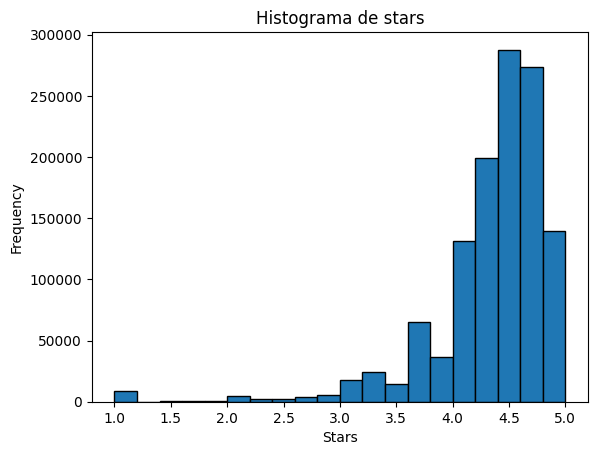

In [ ]:
the ratings are normally distributed